# 02 · Odometry baselines on the hexacopter sequence

This repo ships six individual odometry backends. Here we run **all of them** on
the `indoor_flying1` slice and score each against motion-capture ground truth.

| Method | Streams | Idea |
| --- | --- | --- |
| `imu_only` | IMU | dead-reckoning by integrating the IMU (open loop) |
| `rgb_vo` | grayscale | feature (ORB) visual odometry on APS frames |
| `event_vo` | events | feature VO on accumulated event-edge frames |
| `event_imu` | events + IMU | IMU propagation corrected by event-frame shifts |
| `image_imu` | grayscale + IMU | IMU propagation corrected by RGB-VO |
| `multimodal_vio` | events + grayscale + IMU | fuses both visual cues over IMU |

We build the backend configs with the **same helper the CLI uses**
(`_imu_only_config_for_sequence`, `_ensemble_baselines`) so the numbers match a
`python -m nav_benchmark run …` invocation.

In [1]:
# --- Notebook bootstrap: put the src/ package on the path, pick the dataset ---
import sys, time, warnings
from pathlib import Path

# Find the repo root (the folder that holds pyproject.toml) starting from the
# notebook's working directory, so this runs whether the kernel starts in
# notebooks/ or at the repo root.
ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")  # hide benign divide-by-zero notices from the baselines

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["figure.dpi"] = 92

# The "hexacopter" part of MVSEC is the indoor_flying sequences (a DAVIS346
# event camera + IMU + grayscale rig flown on a hexacopter with motion-capture
# ground truth). We use a pre-converted 15 s slice (5 s -> 20 s) of
# indoor_flying1. Prefer the image-inclusive slice; fall back to events+IMU.
DATA = ROOT / "data"
CANDIDATES = ["indoor_flying1_5s20s_img.h5", "indoor_flying1_5s20s.h5"]
SEQ_PATH = next((DATA / c for c in CANDIDATES if (DATA / c).exists()), None)
assert SEQ_PATH is not None, (
    "No hexacopter slice found under data/. Regenerate one (needs the MVSEC bags) with:\n"
    "  uv run python scripts/convert_mvsec_bag_to_h5.py \\\n"
    "    --data-bag data/indoor_flying1_data.bag --gt-bag data/indoor_flying1_gt.bag \\\n"
    "    --output data/indoor_flying1_5s20s_img.h5 --start-sec 5 --duration-sec 15 --include-images"
)
print("Repo root :", ROOT)
print("Sequence  :", SEQ_PATH.name)

Repo root : /home/jovyan/event-based-vio
Sequence  : indoor_flying1_5s20s_img.h5


In [2]:
import types
from nav_benchmark.datasets.mvsec import load_mvsec_sequence
from nav_benchmark.events.representations import ensure_event_frames
from nav_benchmark.run import _imu_only_config_for_sequence, _ensemble_baselines
from nav_benchmark.evaluation.harness import load_ground_truth_trajectory
from nav_benchmark.evaluation.metrics import evaluate_trajectory, EvalConfig

# nav_benchmark.evaluation.plots forces a headless Agg backend at import time
# (great for the CLI, but it silently disables inline figures). Re-assert the
# inline backend now that those modules are imported, so plots render here.
get_ipython().run_line_magic("matplotlib", "inline")

seq = load_mvsec_sequence(SEQ_PATH)
ensure_event_frames(seq, window_sec=0.05)   # build event-edge frames from raw events

# A tiny stand-in for the CLI's parsed args, used only to build configs.
args = types.SimpleNamespace(dataset="mvsec", input=str(SEQ_PATH),
                             sequence="indoor_flying1", event_window_ms=50.0)
imu_cfg = _imu_only_config_for_sequence(args, seq)
print("gravity:", imu_cfg.gravity, " initial position (from GT):", np.round(imu_cfg.initial_position, 3))

gravity: [0.   0.   9.81]  initial position (from GT): [-0.108 -0.329 -0.543]


## Run every baseline

`_ensemble_baselines` runs all six backends and returns a `{method: Trajectory}`
dict. On a laptop CPU this takes ~30–40 s (event/frame feature matching over the
15 s slice).

In [3]:
t0 = time.perf_counter()
baselines, _ = _ensemble_baselines(args, seq, None, imu_cfg)
print(f"Ran {len(baselines)} baselines in {time.perf_counter()-t0:.1f} s")
for name, traj in sorted(baselines.items()):
    print(f"  {name:16s} {len(traj.timestamps):6d} poses,  method tag = {traj.method}")

Ran 6 baselines in 33.1 s
  event_imu         15010 poses,  method tag = event_imu
  event_vo            300 poses,  method tag = event_vo
  image_imu         15010 poses,  method tag = image_imu
  imu_only          15010 poses,  method tag = imu_only
  multimodal_vio    15010 poses,  method tag = multimodal_vio
  rgb_vo              470 poses,  method tag = rgb_vo


## Score against ground truth

Each trajectory is SE(3)-aligned to the ground truth, then we compute the
benchmark's core metrics: **ATE** (absolute trajectory error, RMSE), **RPE**
(relative pose error over 1 m), **final drift** and **drift %** of path length,
**tracking-failure fraction** (LOST/INVALID poses), plus **latency** and
**odometry rate**.

In [4]:
gt = load_ground_truth_trajectory(SEQ_PATH)
cfg = EvalConfig()

results, rows = {}, []
for name, traj in baselines.items():
    res = evaluate_trajectory(traj, gt, cfg)
    results[name] = res
    m, f, rt = res.metrics, res.failures, res.runtime
    rows.append({
        "method": name,
        "poses": len(traj.timestamps),
        "ATE_rmse_m": round(m.ate_rmse, 3),
        "RPE_rmse_m": round(m.rpe_rmse, 3),
        "final_drift_m": round(m.final_drift, 2),
        "drift_%": None if m.drift_percent is None else round(m.drift_percent, 1),
        "fail_frac": round(f.failed_frame_fraction, 3),
        "latency_ms": None if rt.latency_mean_ms is None else round(rt.latency_mean_ms, 2),
        "odom_Hz": round(rt.odometry_frequency_hz, 1),
    })

table = pd.DataFrame(rows).set_index("method").sort_values("ATE_rmse_m")
table

,poses,ATE_rmse_m,RPE_rmse_m,final_drift_m,drift_%,fail_frac,latency_ms,odom_Hz
method,,,,,,,,
rgb_vo,470,0.385,1.236,0.43,6.5,0.000,8.45,31.4
event_vo,300,0.443,1.057,0.51,7.9,0.000,19.09,20.0
imu_only,15010,28.655,0.989,67.95,68.0,0.753,0.09,1000.7
multimodal_vio,15010,89.050,0.806,1548.34,36.0,0.000,28.46,1000.7
image_imu,15010,159.954,0.969,1430.73,65.6,0.000,8.55,1000.7
event_imu,15010,438.301,0.997,981.18,67.2,0.008,0.44,1000.7


## Estimated paths vs. ground truth (top-down)

Each estimate is aligned into the ground-truth frame, so a perfect method would
trace the black reference exactly.

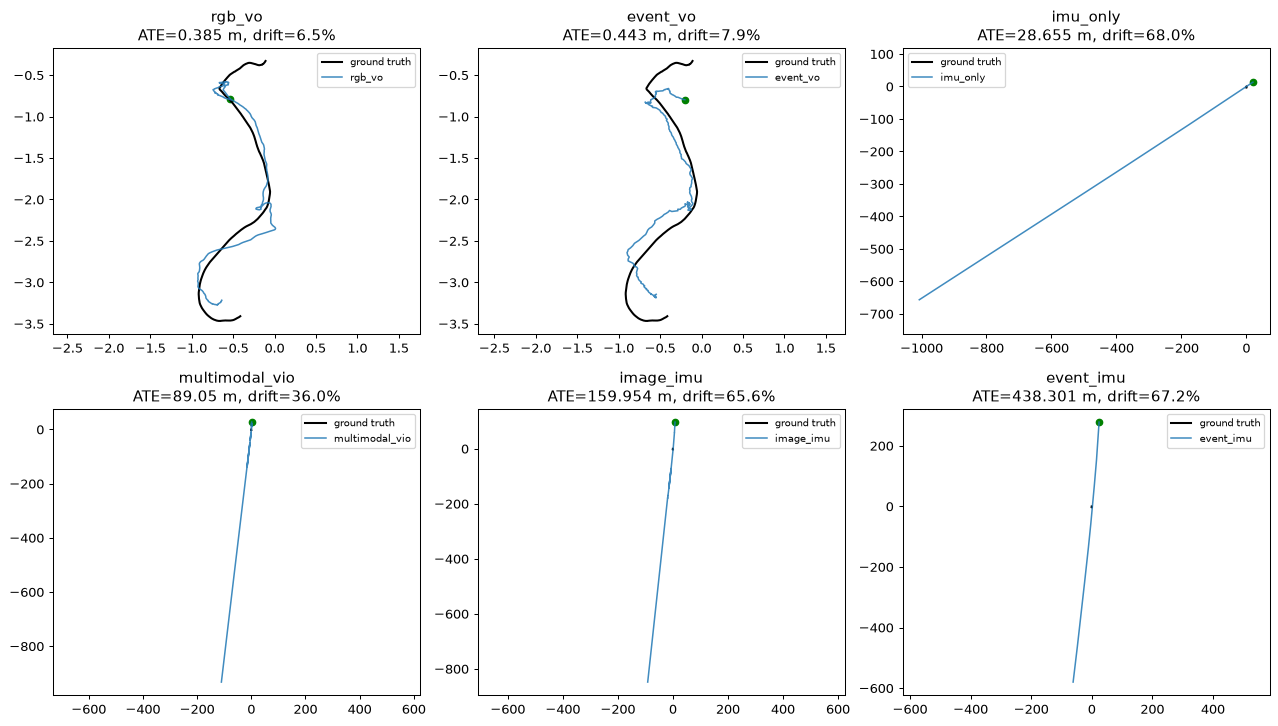

In [5]:
order = table.index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
gt_xy = gt.positions
for ax, name in zip(axes.ravel(), order):
    est = results[name].aligned_estimate.positions
    ax.plot(gt_xy[:, 0], gt_xy[:, 1], "k-", lw=1.6, label="ground truth")
    ax.plot(est[:, 0], est[:, 1], "-", lw=1.2, alpha=0.85, label=name)
    ax.scatter(est[0, 0], est[0, 1], c="g", s=25)
    ax.set_title(f"{name}\nATE={table.loc[name,'ATE_rmse_m']} m, drift={table.loc[name,'drift_%']}%")
    ax.axis("equal"); ax.legend(fontsize=8, loc="best")
plt.tight_layout(); plt.show()

## How error grows with distance travelled

The benchmark bins absolute error against cumulative path length (drift over
distance). Open-loop inertial integration grows without bound; the visual
methods stay comparatively flat.

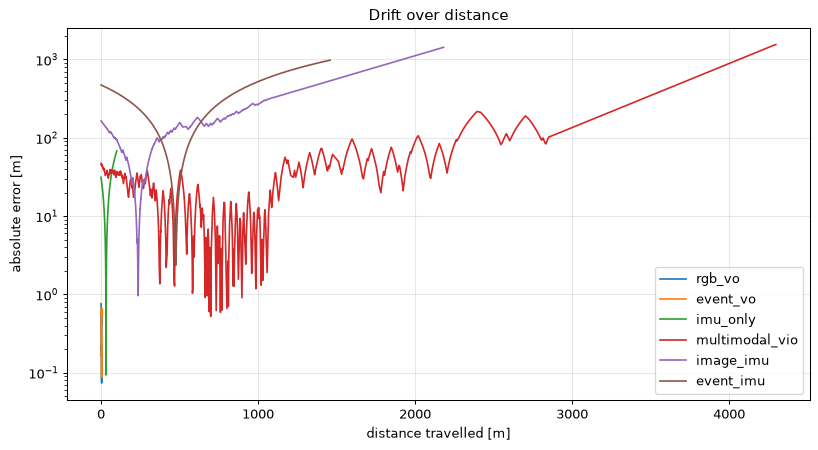

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
for name in order:
    evd = results[name].error_vs_distance
    if not evd:
        continue
    d = np.array([r.cumulative_distance for r in evd])
    e = np.array([r.error_magnitude for r in evd])
    ax.plot(d, e, lw=1.3, label=name)
ax.set_xlabel("distance travelled [m]"); ax.set_ylabel("absolute error [m]")
ax.set_title("Drift over distance"); ax.set_yscale("log"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Honest takeaways

- **This is real, un-tuned MVSEC data** and the numbers are reported honestly —
  the repo's contract is faithful benchmarking, not cherry-picked wins.
- The **feature-VO baselines** (`rgb_vo`, `event_vo`) track best here: they take
  their step *scale* from ground truth (a deliberate baseline simplification),
  so they stay near the true path (ATE well under a metre).
- **`imu_only` drifts** tens of metres over 15 s — the canonical open-loop
  failure the visual cues exist to bound.
- The **IMU-fused variants** (`event_imu`, `image_imu`, `multimodal_vio`) inherit
  a lot of that inertial drift on this clean slice; their event/image corrections
  bound *drift-over-distance* more than absolute ATE. That weak-accuracy result is
  expected and documented — it's the motivation for the **ensembles** in
  [`03_ensembles_hexacopter.ipynb`](03_ensembles_hexacopter.ipynb), which arbitrate
  between backends instead of trusting any single one.